# End-to-End Demo — GNN-BERT Music Context Understanding

This notebook loads one held-out MagnaTagATune test graph, its cached DistilBERT text embedding, and the trained **A4 early-concatenation fusion model**. It then performs one end-to-end inference example and shows the top predicted context tags.


In [1]:
from pathlib import Path
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch_geometric.data import Data

# Works whether the notebook kernel starts in the project root or notebooks/.
cwd = Path.cwd().resolve()
if (cwd / 'src').exists():
    ROOT = cwd
elif (cwd.parent / 'src').exists():
    ROOT = cwd.parent
else:
    raise RuntimeError(f'Could not locate project root from {cwd}')

import sys
sys.path.insert(0, str(ROOT / 'src'))
from gnn_model import ContextModel, make_cfg

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('project root:', ROOT)
print('device:', DEVICE)


G:\CSE425_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


project root: G:\CSE425_Project
device: cuda


In [2]:
# Paths
labels_path = ROOT / 'data' / 'splits' / 'magnatagatune_labels.json'
graphs_dir = ROOT / 'data' / 'processed' / 'graphs' / 'magnatagatune'
bert_path = ROOT / 'data' / 'processed' / 'bert_cache_magnatagatune.pt'
ckpt_path = ROOT / 'results' / 'checkpoints' / 'magnatagatune_MTT_A4_s425.pt'

for p in [labels_path, graphs_dir, bert_path, ckpt_path]:
    print(p, 'OK' if p.exists() else 'MISSING')


G:\CSE425_Project\data\splits\magnatagatune_labels.json OK
G:\CSE425_Project\data\processed\graphs\magnatagatune OK
G:\CSE425_Project\data\processed\bert_cache_magnatagatune.pt OK
G:\CSE425_Project\results\checkpoints\magnatagatune_MTT_A4_s425.pt OK


In [3]:
# Load metadata and frozen BERT cache
labels = json.load(open(labels_path, encoding='utf-8'))
bert = torch.load(bert_path, map_location='cpu', weights_only=False)
bert_idx = {tid: i for i, tid in enumerate(bert['ids'])}

# Pick a held-out test example that has genuine text context when possible.
chosen = None
for f in sorted(graphs_dir.glob('*.pt')):
    r = torch.load(f, map_location='cpu', weights_only=False)
    if r['split'] == 'test' and r['track_id'] in bert_idx and r.get('text', '') != 'unlabelled audio':
        chosen = (f, r)
        break

if chosen is None:
    for f in sorted(graphs_dir.glob('*.pt')):
        r = torch.load(f, map_location='cpu', weights_only=False)
        if r['split'] == 'test' and r['track_id'] in bert_idx:
            chosen = (f, r)
            break

assert chosen is not None, 'No usable test graph found.'
graph_file, r = chosen
tid = r['track_id']
j = bert_idx[tid]

print('track_id:', tid)
print('split:', r['split'])
print('text context:', r['text'])
print('nodes:', r['x'].shape[0], 'feature dim:', r['x'].shape[1], 'edges:', r['edge_index'].shape[1])


track_id: d__ambient_teknology-the_all_seeing_eye_project-01-cyclops-117-146
split: test
text context: slow
nodes: 29 feature dim: 63 edges: 180


In [4]:
# Reconstruct the exact single-graph input format used by train.py
d = Data(
    x=r['x'].float(),
    edge_index=r['edge_index'].long(),
    edge_type=r['edge_type'].long(),
)
d.y = r['y'].float().unsqueeze(0)
d.text_cls = bert['cls'][j].float().unsqueeze(0)
d.text_tokens = bert['tokens'][j].float().unsqueeze(0)
d.text_mask = bert['mask'][j].float().unsqueeze(0)
d.track_id = tid
d.batch = torch.zeros(d.x.shape[0], dtype=torch.long)

# Load the trained A4 model/checkpoint.
ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
target_tags = ckpt['target_tags']
mcfg = make_cfg('A4', n_classes=len(target_tags), hidden=128, in_dim=d.x.shape[1])
model = ContextModel(mcfg)
model.load_state_dict(ckpt['state_dict'])
model = model.to(DEVICE).eval()
thresholds = np.asarray(ckpt['thresholds'], dtype=float)

with torch.no_grad():
    out = model(d.to(DEVICE))
    probs = torch.sigmoid(out['logits']).squeeze(0).cpu().numpy()

print('checkpoint loaded:', ckpt_path.name)
print('output shape:', probs.shape)


checkpoint loaded: magnatagatune_MTT_A4_s425.pt
output shape: (20,)


In [5]:
# Inspect predictions
y_true = r['y'].cpu().numpy().astype(int)
true_tags = [t for t, y in zip(target_tags, y_true) if y == 1]
pred_tags = [t for t, p, th in zip(target_tags, probs, thresholds) if p >= th]

top_idx = np.argsort(-probs)[:10]
print('TEXT INPUT :', r['text'])
print('TRUE TAGS  :', true_tags if true_tags else '(none among the selected 20 targets)')
print('PREDICTED  :', pred_tags if pred_tags else '(none above validation-tuned thresholds)')
print('\nTop-10 probabilities:')
for k in top_idx:
    mark = '*' if y_true[k] else ' '
    print(f'{mark} {target_tags[k]:<15s}  p={probs[k]:.3f}  threshold={thresholds[k]:.2f}')


TEXT INPUT : slow
TRUE TAGS  : ['ambient']
PREDICTED  : ['ambient', 'new age']

Top-10 probabilities:
* ambient          p=0.871  threshold=0.75
  new age          p=0.233  threshold=0.05
  techno           p=0.231  threshold=0.75
  rock             p=0.122  threshold=0.95
  electronic       p=0.113  threshold=0.35
  weird            p=0.036  threshold=0.05
  dance            p=0.030  threshold=0.45
  modern           p=0.029  threshold=0.40
  classical        p=0.028  threshold=0.65
  country          p=0.019  threshold=0.75


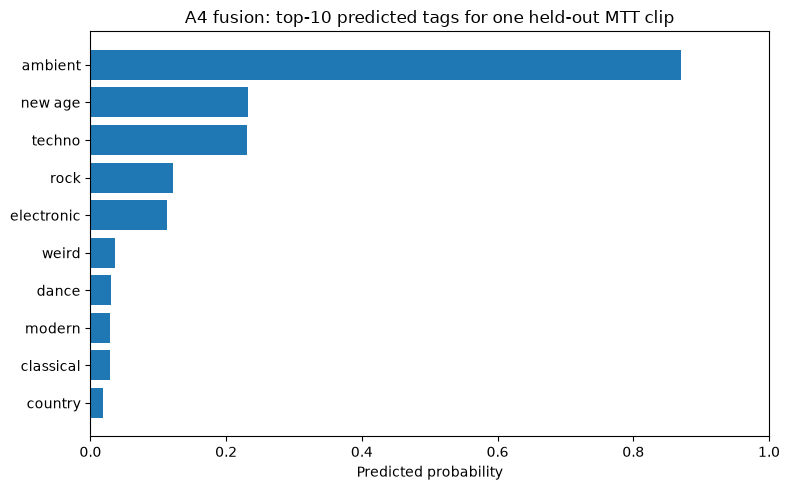

In [6]:
# Report-friendly visualization for this inference example
plot_idx = top_idx[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([target_tags[k] for k in plot_idx], [probs[k] for k in plot_idx])
ax.set_xlabel('Predicted probability')
ax.set_title('A4 fusion: top-10 predicted tags for one held-out MTT clip')
ax.set_xlim(0, 1)
fig.tight_layout()
plt.show()


## What this demonstrates

The example runs the same inference path used during evaluation: **segment graph + cached BERT context → trained multimodal fusion model → multi-label tag probabilities → validation-tuned decision thresholds**. The example is selected only from the held-out test partition.
